In [187]:
from collections import Counter
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import roc_auc_score
import torch.nn.functional as F
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import pickle

### 1. Введение

1. Типы задач рекуррентных нейронных сетей:
- Анализ текста и естественного языка (определение языка, анализ тональности, генерация текста)
- Обработка временных рядов (прогнозирование спроса, погоды, сигналов датчиков)
- Последовательности символов/аудио (распознавание речи, синтез речи)
- Работа с последовательностями в рекомендациях (учет последовательности действий пользователя)

2. Типы формулировок задач:
- Один ко многим (1 → N) На вход подаётся единичный объект, на выходе — последовательность
    - Изображение → подпись к изображению
    - Тип жанра музыки → сгенерированная мелодия
- Многие ко многим (N → N) На вход — последовательность, на выход — последовательность
    - Перевод текста (каждое слово входа → слово выхода)
    - Распознавание речи (аудио → текст)
- Многие к одному (N → 1) На вход — последовательность, на выход — один объект
    - Классификация текста (определить эмоцию по сообщению)
    - Определить язык слова или предложения

3. Пример RNN

```
h0 = [0, 0, 0, ..., 0] Инициализация скрытого состояния RNN нулями
П → Emb → x1 → (Wxh * x1 + Whh * h0 + b) → tanh → h1
р → Emb → x2 → (Wxh * x2 + Whh * h1 + b) → tanh → h2
и → Emb → x3 → (Wxh * x3 + Whh * h2 + b) → tanh → h3
в → Emb → x4 → (Wxh * x4 + Whh * h3 + b) → tanh → h4    
е → Emb → x5 → (Wxh * x5 + Whh * h4 + b) → tanh → h5
т → Emb → x6 → (Wxh * x6 + Whh * h5 + b) → tanh → h6
                                               ↓                                            
                                          Output Layer
```  

![](data/rnn.png)
                         


4. Различия архитектур RNN, LSTM и GRU

| Архитектура | Архитектура / компоненты | Реализация | Плюсы | Минусы |
|-------------|-------------------------|------------|-------|--------|
| RNN         | Одно скрытое состояние, обновляется на каждом шаге | На каждом шаге текущее состояние зависит от входа и предыдущего состояния | Простая, мало параметров, быстро работает | Плохо запоминает длинные последовательности, возможны затухание или взрыв градиентов |
| LSTM        | Долгосрочная память и скрытое состояние; три ворота: forget, input, output | Ворота решают, что забыть, что добавить и что использовать для выхода; память позволяет хранить информацию на длинные последовательности | Отлично хранит долгие зависимости, устойчива к затуханию градиентов | Сложная, много параметров, медленнее обучение |
| GRU         | Одно скрытое состояние; два ворота: update и reset | Ворота контролируют, сколько прошлой информации использовать и насколько обновлять состояние; информация хранится в скрытом состоянии | Меньше параметров, быстрее LSTM, хорошо хранит долгие зависимости | Чуть меньше гибкости, чем LSTM для очень сложных задач |


![](data/img.png)



    

### 2. Анализ данных

Распределение по полу: Gender
boy     3437
girl    3345
Name: count, dtype: int64
Частота букв :        Count
Letter       
a        5593
e        5038
n        3524
i        3264
l        3255
r        3070
o        2071
t        1745
s        1674
d        1532
m        1245
y        1243
h        1206
c        1063
u         707
b         673
k         616
g         526
j         502
v         490
f         302
w         271
p         265
z         199
x          71
q          61


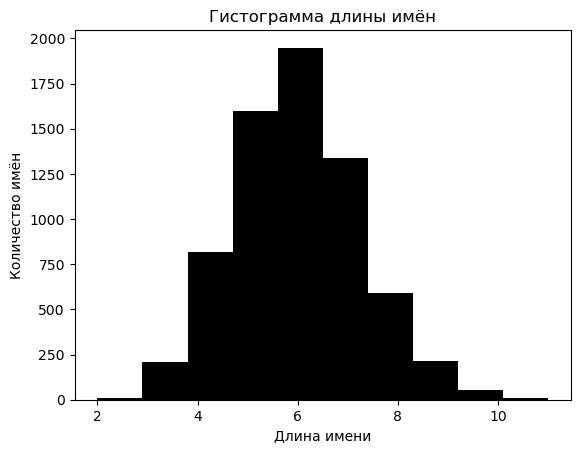

In [2]:
df = pd.read_csv('data/babynames-clean.csv', names=['Name', 'Gender'])

plt.hist(df['Name'].apply(len), bins=df['Name'].apply(len).max() - 1, color='black')
plt.title('Гистограмма длины имён')
plt.xlabel('Длина имени')
plt.ylabel('Количество имён')

print(f'Распределение по полу: {df["Gender"].value_counts()}')

all_letters = ''.join(df['Name'].str.lower())
letter_counts = Counter(all_letters)
df_letters = pd.DataFrame(list(letter_counts.items()), columns=['Letter', 'Count'])
df_letters.index = df_letters.Letter
df_letters.drop('Letter', axis=1, inplace=True)
print(f"Частота букв :{df_letters.sort_values('Count', ascending=False)}")

### 3. Подготовка данных

In [3]:
all_chars = [chr(i) for i in range(97, 123)]
all_chars.extend(['<SOS>', '<EOS>', ' '])
token_to_id = {char: idx for idx, char in enumerate(all_chars)}
id_to_token = {idx: char for char, idx in token_to_id.items()}


def encode_name(name):
    tokens = ['<SOS>'] + list(name.lower()) + ['<EOS>']  # имя -> токены
    while len(tokens) < 13:
        tokens.append(' ')
    return [token_to_id[t] for t in tokens]


df['Encoded'] = df['Name'].apply(encode_name)
print(df.head(3))

      Name Gender                                            Encoded
0     John    boy  [26, 9, 14, 7, 13, 27, 28, 28, 28, 28, 28, 28,...
1  William    boy  [26, 22, 8, 11, 11, 8, 0, 12, 27, 28, 28, 28, 28]
2    James    boy  [26, 9, 0, 12, 4, 18, 27, 28, 28, 28, 28, 28, 28]


In [4]:
train, temp = train_test_split(df, test_size=0.2, random_state=21, stratify=df['Gender'])
valid, test = train_test_split(temp, test_size=0.5, random_state=21, stratify=temp['Gender'])

# Преобразуем метки пола в 0/1 для всех наборов
train['Gender'] = train['Gender'].apply(lambda x: 0 if x == 'boy' else 1)
valid['Gender'] = valid['Gender'].apply(lambda x: 0 if x == 'boy' else 1)
test['Gender'] = test['Gender'].apply(lambda x: 0 if x == 'boy' else 1)

print(train.shape, valid.shape, test.shape)

(5425, 3) (678, 3) (679, 3)


### 4. Рекуррентная нейронная сеть RNN

In [5]:
class Model(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, gender_output=True, dropout=0.0, type='RNN'):
        super().__init__()
        self.type = type
        self.hidden_size = hidden_size
        self.gender_output = gender_output

        # Слой эмбеддингов
        self.embedding = nn.Embedding(vocab_size, embed_size)

        # RNN блок
        if type == 'RNN':
            self.W_xh = nn.Linear(embed_size, hidden_size)
            self.W_hh = nn.Linear(hidden_size, hidden_size)

        # GRU блок
        elif type == 'GRU':
            self.W_xz = nn.Linear(embed_size, hidden_size)
            self.W_hz = nn.Linear(hidden_size, hidden_size)
            self.W_xr = nn.Linear(embed_size, hidden_size)
            self.W_hr = nn.Linear(hidden_size, hidden_size)
            self.W_xh = nn.Linear(embed_size, hidden_size)
            self.W_hh = nn.Linear(hidden_size, hidden_size)

        # LSTM блок
        elif type == 'LSTM':
            # Input gate
            self.W_xi = nn.Linear(embed_size, hidden_size)
            self.W_hi = nn.Linear(hidden_size, hidden_size)
            # Forget gate
            self.W_xf = nn.Linear(embed_size, hidden_size)
            self.W_hf = nn.Linear(hidden_size, hidden_size)
            # Output gate
            self.W_xo = nn.Linear(embed_size, hidden_size)
            self.W_ho = nn.Linear(hidden_size, hidden_size)
            # Candidate cell
            self.W_xc = nn.Linear(embed_size, hidden_size)
            self.W_hc = nn.Linear(hidden_size, hidden_size)

        else:
            raise ValueError(f"Unknown rnn_type {type}. Choose from ['RNN','GRU','LSTM'].")

        # Dropout
        self.dropout = nn.Dropout(dropout) if dropout > 0 else None

        # Линейный слой для предсказания следующего токена
        self.fc_token = nn.Linear(hidden_size, vocab_size)

        # Линейный слой для предсказания пола
        if gender_output:
            self.fc_gender = nn.Linear(hidden_size, 1)  # бинарная классификация

    def init_hidden(self, batch_size, device):
        if self.type == 'LSTM':
            h = torch.zeros(batch_size, self.hidden_size, device=device)
            c = torch.zeros(batch_size, self.hidden_size, device=device)
            return (h, c)
        else:
            return torch.zeros(batch_size, self.hidden_size, device=device)

    def forward(self, x, hidden=None):
        """
        x: [batch_size, seq_len] - последовательности токенов
        hidden: скрытое состояние (для LSTM - tuple(h,c), иначе tensor)
        """
        batch_size, seq_len = x.size()
        if hidden is None:
            hidden = self.init_hidden(batch_size, x.device)

        logits_tokens = []

        if self.type == 'RNN':
            for t in range(seq_len):
                emb = self.embedding(x[:, t])
                hidden = torch.tanh(self.W_xh(emb) + self.W_hh(hidden))
                if self.dropout:
                    hidden = self.dropout(hidden)
                logits_tokens.append(self.fc_token(hidden))

        elif self.type == 'GRU':
            for t in range(seq_len):
                emb = self.embedding(x[:, t])
                h_prev = hidden
                z = torch.sigmoid(self.W_xz(emb) + self.W_hz(h_prev))
                r = torch.sigmoid(self.W_xr(emb) + self.W_hr(h_prev))
                h_tilde = torch.tanh(self.W_xh(emb) + self.W_hh(r * h_prev))
                hidden = (1 - z) * h_prev + z * h_tilde
                if self.dropout:
                    hidden = self.dropout(hidden)
                logits_tokens.append(self.fc_token(hidden))

        elif self.type == 'LSTM':
            h, c = hidden
            for t in range(seq_len):
                emb = self.embedding(x[:, t])
                i = torch.sigmoid(self.W_xi(emb) + self.W_hi(h))
                f = torch.sigmoid(self.W_xf(emb) + self.W_hf(h))
                o = torch.sigmoid(self.W_xo(emb) + self.W_ho(h))
                c_tilde = torch.tanh(self.W_xc(emb) + self.W_hc(h))
                c = f * c + i * c_tilde
                h = o * torch.tanh(c)
                if self.dropout:
                    h = self.dropout(h)
                logits_tokens.append(self.fc_token(h))
            hidden = (h, c)

        # Собираем логиты токенов
        logits_tokens = torch.stack(logits_tokens, dim=1)  # [batch_size, seq_len, vocab_size]

        # Логит пола
        if self.gender_output:
            if self.type == 'LSTM':
                logits_gender = self.fc_gender(hidden[0])
            else:
                logits_gender = self.fc_gender(hidden)
            prob_gender = torch.sigmoid(logits_gender)
        else:
            logits_gender = None
            prob_gender = None

        return logits_tokens, prob_gender, logits_gender, hidden


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Используем устройство:", device)

# Преобразуем список токенов в тензор

train_tensor = torch.tensor(list(train['Encoded'].values), dtype=torch.long)  # [num_samples, seq_len]
valid_tensor = torch.tensor(list(valid['Encoded'].values), dtype=torch.long)  # [num_samples, seq_len]

test_sequences = torch.tensor(list(test['Encoded'].values),
                              dtype=torch.long)  # [num_samples, seq_len] # Последовательности токенов для теста
test_genders = torch.tensor(test['Gender'].values, dtype=torch.float)  # [num_samples] Метки пола

batch_size = 64  # Размер batch

train_dataset = TensorDataset(train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

valid_dataset = TensorDataset(valid_tensor)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=True)

test_dataset = TensorDataset(test_sequences, test_genders)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Инициализация модели
vocab_size = len(token_to_id)  # 29
embed_size = 128
hidden_size = 256


def train_epoch(model, train_loader, optimizer, criterion):
    model.train()
    epoch_train_loss = 0
    for batch in train_loader:
        x_batch = batch[0].to(device)

        # Forward pass
        logits_tokens, _, _, _ = model(x_batch)
        logits = logits_tokens[:, :-1, :]
        targets = x_batch[:, 1:]

        # Reshape для CrossEntropyLoss
        logits = logits.reshape(-1, vocab_size)
        targets = targets.reshape(-1)

        loss = criterion(logits, targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()

    # усредняем по батчам
    return epoch_train_loss / len(train_loader)


def validate_epoch(model, valid_loader, criterion):
    model.eval()
    epoch_valid_loss = 0
    with torch.no_grad():
        for batch in valid_loader:
            x_batch = batch[0].to(device)

            logits_tokens, _, _, _ = model(x_batch)
            logits = logits_tokens[:, :-1, :]
            targets = x_batch[:, 1:]
            logits = logits.reshape(-1, vocab_size)
            targets = targets.reshape(-1)

            loss = criterion(logits, targets)
            epoch_valid_loss += loss.item()

    return epoch_valid_loss / len(valid_loader)

Используем устройство: cuda


In [7]:
# Обучение модели с сохранением потерь
def train_model(model, train_loader, valid_loader, optimizer, criterion, epochs=100, epochs_train=0, patience=3,
                gender_mode=False):
    best_valid_loss = float('inf')
    counter = 0
    train_losses = []
    valid_losses = []

    for epoch in range(epochs):

        if gender_mode:
            train_loss = train_epoch_gender(model, train_loader, optimizer, criterion)
            valid_loss = validate_epoch_gender(model, valid_loader, criterion)
        else:
            train_loss = train_epoch(model, train_loader, optimizer, criterion)
            valid_loss = validate_epoch(model, valid_loader, criterion)

        train_losses.append(train_loss)
        valid_losses.append(valid_loss)

        print(f"Epoch {epoch + 1}/{epochs} finished. Train Loss: {train_loss:.4f}, Valid Loss: {valid_loss:.4f}")
        epochs_train += 1

        # Early stopping
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print(f"No improvement in valid loss for {patience} epochs. Stopping training.")
                break

    return train_losses, valid_losses, epochs_train

In [8]:
# Генерация имени на основе обученной модели
def generate_name(model, start_char='<SOS>', max_len=12, temperature=1.0, device='cpu'):
    """    
    Параметры:
    - model: обученная RNN
    - start_char: символ, с которого начинается имя ('<SOS>' по умолчанию)
    - max_len: максимальная длина генерируемого имени (без <SOS>)
    - temperature: параметр стохастичности. Чем выше, тем более случайные буквы.
    - device: 'cpu' или 'cuda'
    
    Возвращает:
    - сгенерированное имя (строку)
    """
    model.eval()  # переводим модель в режим оценки
    with torch.no_grad():  # отключаем вычисление градиентов

        # 1. Инициализация скрытого состояния
        hidden = model.init_hidden(1, device)  # batch_size = 1

        # 2. Начальный токен
        input_id = torch.tensor([[token_to_id[start_char]]], device=device)  # [1,1]

        name_generated = []  # сюда будем накапливать буквы

        for _ in range(max_len):
            # forward pass для одного шага
            logits_tokens, _, _, hidden = model(input_id, hidden)  # logits_tokens: [1,1,vocab_size]
            logits = logits_tokens[:, -1, :]  # берём последний шаг: [1, vocab_size]

            # 3. Применяем температуру и softmax для получения вероятностей
            probs = torch.softmax(logits / temperature, dim=-1)  # [1, vocab_size]

            # 4. Стохастическое выбор следующей буквы
            next_id = torch.multinomial(probs, num_samples=1)  # [1,1]

            # 5. Преобразуем индекс обратно в символ
            char = id_to_token[int(next_id)]

            # 6. Если встретили <EOS>, заканчиваем генерацию
            if char == '<EOS>':
                break

            # 7. Добавляем символ в имя
            name_generated.append(char)

            # 8. Используем сгенерированный токен как следующий input
            input_id = next_id

        return ''.join(name_generated)

In [9]:
def evaluation_model(model, epochs_train, train_losses, valid_losses):
    # График сходимости потерь
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, epochs_train + 1), train_losses, label='Train Loss')
    plt.plot(range(1, epochs_train + 1), valid_losses, label='Valid Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('График сходимости потерь')
    plt.legend()
    plt.show()

    # Генерация имен
    model.eval()  # режим оценки
    for _ in range(10):
        name = generate_name(model, start_char='<SOS>', max_len=12, temperature=0.5, device=device)
        print(f"{_ + 1}. Сгенерированное имя: {name}")

    # AUC ROC
    y_true = []
    y_pred = []

    model.eval()
    with torch.no_grad():
        for batch in test_loader:
            x_batch = batch[0].to(device)
            gender_labels = batch[1].to(device).float()  # 0=boy, 1=girl

            _, prob_gender, _, _ = model(x_batch)
            prob_gender = prob_gender.squeeze()  # [batch_size]

            y_true.extend(gender_labels.cpu().numpy())
            y_pred.extend(prob_gender.cpu().numpy())

    auc = roc_auc_score(y_true, y_pred)
    print(f"AUC ROC: {auc:.4f}")

Epoch 1/100 finished. Train Loss: 1.4737, Valid Loss: 1.3056
Epoch 2/100 finished. Train Loss: 1.2523, Valid Loss: 1.2647
Epoch 3/100 finished. Train Loss: 1.2150, Valid Loss: 1.2395
Epoch 4/100 finished. Train Loss: 1.1891, Valid Loss: 1.2198
Epoch 5/100 finished. Train Loss: 1.1675, Valid Loss: 1.2101
Epoch 6/100 finished. Train Loss: 1.1495, Valid Loss: 1.2062
Epoch 7/100 finished. Train Loss: 1.1329, Valid Loss: 1.1908
Epoch 8/100 finished. Train Loss: 1.1172, Valid Loss: 1.1838
Epoch 9/100 finished. Train Loss: 1.1035, Valid Loss: 1.1795
Epoch 10/100 finished. Train Loss: 1.0926, Valid Loss: 1.1794
Epoch 11/100 finished. Train Loss: 1.0780, Valid Loss: 1.1705
Epoch 12/100 finished. Train Loss: 1.0661, Valid Loss: 1.1641
Epoch 13/100 finished. Train Loss: 1.0551, Valid Loss: 1.1598
Epoch 14/100 finished. Train Loss: 1.0445, Valid Loss: 1.1561
Epoch 15/100 finished. Train Loss: 1.0347, Valid Loss: 1.1637
Epoch 16/100 finished. Train Loss: 1.0245, Valid Loss: 1.1613
Epoch 17/100 fini

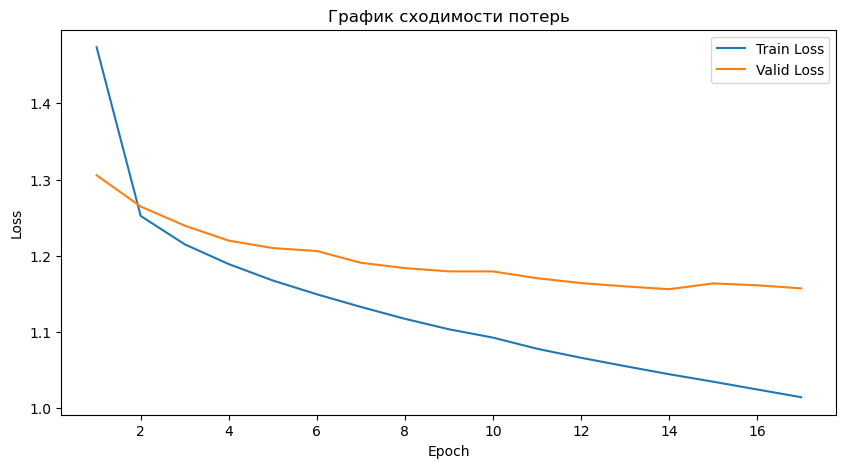

1. Сгенерированное имя: aliva
2. Сгенерированное имя: sam
3. Сгенерированное имя: malika
4. Сгенерированное имя: charlene
5. Сгенерированное имя: arthea
6. Сгенерированное имя: gaylen
7. Сгенерированное имя: alissa
8. Сгенерированное имя: margell
9. Сгенерированное имя: brown
10. Сгенерированное имя: lora
AUC ROC: 0.5686


In [10]:
# RNN Model

rnn = Model(vocab_size, embed_size, hidden_size, type='RNN').to(device)

# Функция потерь и оптимизатор
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(rnn.parameters(), lr=1e-3)

train_losses, valid_losses, epochs_train = train_model(rnn, train_loader, valid_loader, optimizer, criterion)
evaluation_model(rnn, epochs_train, train_losses, valid_losses)

### 5. GRU

Epoch 1/100 finished. Train Loss: 1.5228, Valid Loss: 1.3209
Epoch 2/100 finished. Train Loss: 1.2520, Valid Loss: 1.2551
Epoch 3/100 finished. Train Loss: 1.2006, Valid Loss: 1.2211
Epoch 4/100 finished. Train Loss: 1.1672, Valid Loss: 1.2071
Epoch 5/100 finished. Train Loss: 1.1388, Valid Loss: 1.1882
Epoch 6/100 finished. Train Loss: 1.1136, Valid Loss: 1.1822
Epoch 7/100 finished. Train Loss: 1.0906, Valid Loss: 1.1691
Epoch 8/100 finished. Train Loss: 1.0686, Valid Loss: 1.1555
Epoch 9/100 finished. Train Loss: 1.0490, Valid Loss: 1.1501
Epoch 10/100 finished. Train Loss: 1.0286, Valid Loss: 1.1518
Epoch 11/100 finished. Train Loss: 1.0098, Valid Loss: 1.1467
Epoch 12/100 finished. Train Loss: 0.9911, Valid Loss: 1.1436
Epoch 13/100 finished. Train Loss: 0.9755, Valid Loss: 1.1467
Epoch 14/100 finished. Train Loss: 0.9593, Valid Loss: 1.1477
Epoch 15/100 finished. Train Loss: 0.9440, Valid Loss: 1.1491
No improvement in valid loss for 3 epochs. Stopping training.


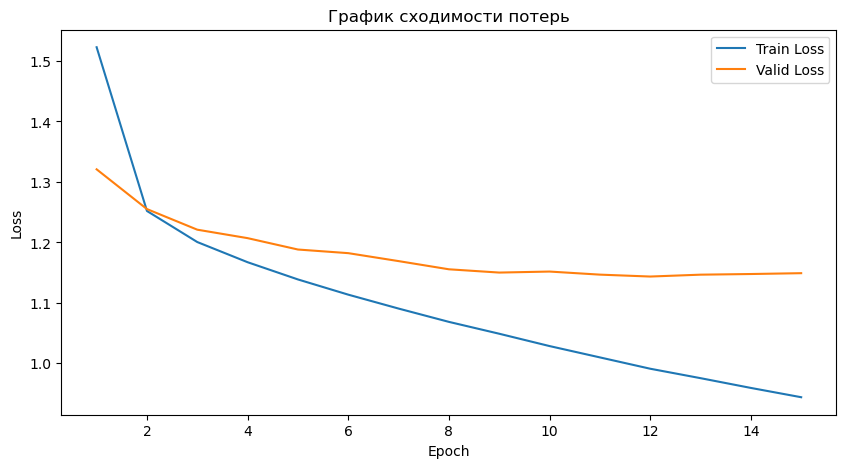

1. Сгенерированное имя: delore
2. Сгенерированное имя: salon
3. Сгенерированное имя: elisa
4. Сгенерированное имя: makayla
5. Сгенерированное имя: claren
6. Сгенерированное имя: arlene
7. Сгенерированное имя: derric
8. Сгенерированное имя: jacquelin
9. Сгенерированное имя: toy
10. Сгенерированное имя: adela
AUC ROC: 0.5025


In [11]:
# GRU Model

gru = Model(vocab_size, embed_size, hidden_size, type='GRU').to(device)

# Функция потерь и оптимизатор
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(gru.parameters(), lr=1e-3)

train_losses, valid_losses, epochs_train = train_model(gru, train_loader, valid_loader, optimizer, criterion)
evaluation_model(gru, epochs_train, train_losses, valid_losses)

### 6. LSTM

Epoch 1/100 finished. Train Loss: 1.6047, Valid Loss: 1.3476
Epoch 2/100 finished. Train Loss: 1.2676, Valid Loss: 1.2649
Epoch 3/100 finished. Train Loss: 1.2120, Valid Loss: 1.2353
Epoch 4/100 finished. Train Loss: 1.1750, Valid Loss: 1.2079
Epoch 5/100 finished. Train Loss: 1.1465, Valid Loss: 1.1881
Epoch 6/100 finished. Train Loss: 1.1198, Valid Loss: 1.1808
Epoch 7/100 finished. Train Loss: 1.0965, Valid Loss: 1.1629
Epoch 8/100 finished. Train Loss: 1.0756, Valid Loss: 1.1560
Epoch 9/100 finished. Train Loss: 1.0544, Valid Loss: 1.1489
Epoch 10/100 finished. Train Loss: 1.0363, Valid Loss: 1.1429
Epoch 11/100 finished. Train Loss: 1.0186, Valid Loss: 1.1354
Epoch 12/100 finished. Train Loss: 1.0028, Valid Loss: 1.1351
Epoch 13/100 finished. Train Loss: 0.9871, Valid Loss: 1.1343
Epoch 14/100 finished. Train Loss: 0.9724, Valid Loss: 1.1315
Epoch 15/100 finished. Train Loss: 0.9587, Valid Loss: 1.1346
Epoch 16/100 finished. Train Loss: 0.9466, Valid Loss: 1.1337
Epoch 17/100 fini

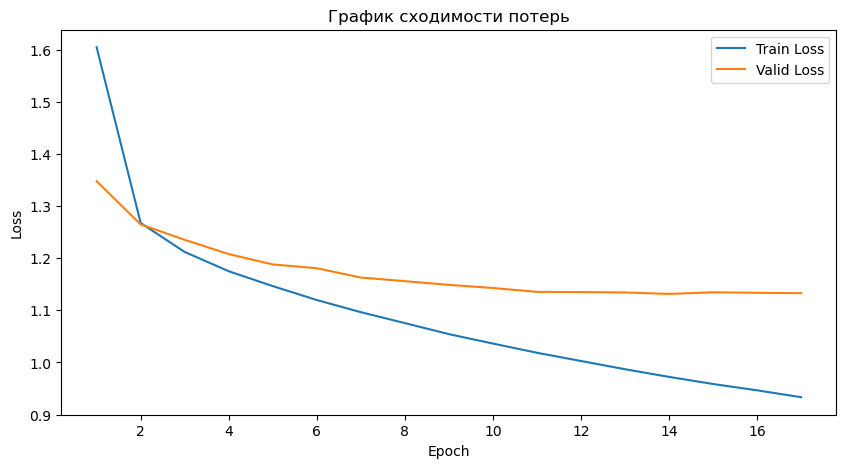

1. Сгенерированное имя: carman
2. Сгенерированное имя: jane
3. Сгенерированное имя: elmory
4. Сгенерированное имя: stephani
5. Сгенерированное имя: kathy
6. Сгенерированное имя: darryn
7. Сгенерированное имя: davian
8. Сгенерированное имя: darrin
9. Сгенерированное имя: shante
10. Сгенерированное имя: debber
AUC ROC: 0.5820


In [12]:
# LSTM Model

lstm = Model(vocab_size, embed_size, hidden_size, type='LSTM').to(device)

# Функция потерь и оптимизатор
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(lstm.parameters(), lr=1e-3)

train_losses, valid_losses, epochs_train = train_model(lstm, train_loader, valid_loader, optimizer, criterion)
evaluation_model(lstm, epochs_train, train_losses, valid_losses)

### 7. Сравнение моделей

**Perplexity** — числовая метрика, которая измеряет степень неопределённости языковой модели относительно предсказания следующей буквы или слова в последовательности 

Чем меньше перплексия, тем лучше модель предсказывает данные, на которых она обучена
Если модель точно воспроизводит вероятности появления слов, её перплексия приближается к единице — это идеальный, но недостижимый предел

**P = exp( - (1/N) Σ log p(wᵢ) )**

**Связь этой метрики с кросс-энтропийными потерями:**

Кросс-энтропия для модели и истинных последовательностей:

**CE = - (1/N) Σ log p(wᵢ)**

Перплексия — это просто экспонента от кросс-энтропии:

**P = exp(CE)**

То есть:

- Кросс-энтропия измеряет среднюю потерю на уровне логитов (в логах)

- Перплексия переводит это в более интуитивную шкалу “сколько вариантов модель рассматривает на каждом шаге”

- Меньшая кросс-энтропия → меньшая перплексия → более точная и уверенная модель


In [13]:
# Перплексия через кросс-энтропию
def perplexity_cross_entropy(logits, targets):
    """
    logits: [batch_size, seq_len, vocab_size] - выход модели
    targets: [batch_size, seq_len] - истинные индексы токенов
    """
    batch_size, seq_len, vocab_size = logits.shape

    # reshape для CrossEntropyLoss
    logits = logits.reshape(-1, vocab_size)  # [(batch_size*seq_len), vocab_size]
    targets = targets.reshape(-1)  # [(batch_size*seq_len)]

    # вычисляем кросс-энтропию
    ce_loss = F.cross_entropy(logits, targets, reduction='mean')

    # перплексия = exp(средняя кросс-энтропия)
    return torch.exp(ce_loss).item()


# Перплексия напрямую из вероятностей (без кросс-энтропии)
def perplexity_probs(probs, targets):
    """
    probs: [batch_size, seq_len, vocab_size] - вероятности после softmax
    targets: [batch_size, seq_len] - истинные индексы
    """
    batch_size, seq_len, vocab_size = probs.shape

    # собираем вероятности правильных токенов
    p_correct = probs.gather(2, targets.unsqueeze(-1)).squeeze(-1)  # [batch_size, seq_len]

    # средний логарифм вероятности
    log_mean = -torch.mean(torch.log(p_correct))

    # перплексия
    return torch.exp(log_mean).item()

In [14]:
vocab_size = 29
seq_len = 13
batch_size = 64

targets = torch.randint(0, vocab_size, (batch_size, seq_len))

# Случайная модель
probs_random = torch.ones(batch_size, seq_len, vocab_size) / vocab_size

perp_random = perplexity_probs(probs_random, targets)
print("Perplexity случайной модели:", perp_random)

Perplexity случайной модели: 28.999990463256836


In [15]:
targets = torch.tensor(
    np.vstack(df['Encoded'].values),
    dtype=torch.long
)

batch_size, seq_len = targets.shape

counter = Counter(targets.flatten().tolist())
vocab_size = max(counter.keys()) + 1
freqs = torch.zeros(vocab_size, dtype=torch.float)

for k, v in counter.items():
    freqs[k] = v

freqs = freqs / freqs.sum()

probs_popular = freqs.unsqueeze(0).unsqueeze(0)
probs_popular = probs_popular.repeat(batch_size, seq_len, 1)

perp_popular = perplexity_probs(probs_popular, targets)
print("Perplexity модели с наиболее популярными буквами:", perp_popular)

Perplexity модели с наиболее популярными буквами: 11.156719207763672


In [16]:
def model_perplexity(model, data_loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_tokens = 0

    with torch.no_grad():
        for batch in data_loader:
            x = batch[0].to(device)  # [batch_size, seq_len]

            logits, _, _, _ = model(x)
            logits = logits[:, :-1, :]  # [batch, seq_len-1, vocab]
            targets = x[:, 1:]  # [batch, seq_len-1]

            logits = logits.reshape(-1, logits.size(-1))
            targets = targets.reshape(-1)

            loss = criterion(logits, targets)

            total_loss += loss.item() * targets.size(0)
            total_tokens += targets.size(0)

    avg_loss = total_loss / total_tokens
    perplexity = torch.exp(torch.tensor(avg_loss))

    return perplexity.item()


ppl_rnn = model_perplexity(rnn, valid_loader, criterion, device)
ppl_gru = model_perplexity(gru, valid_loader, criterion, device)
ppl_lstm = model_perplexity(lstm, valid_loader, criterion, device)

print(f"RNN  Perplexity: {ppl_rnn:.2f}")
print(f"GRU  Perplexity: {ppl_gru:.2f}")
print(f"LSTM Perplexity: {ppl_lstm:.2f}")

RNN  Perplexity: 3.18
GRU  Perplexity: 3.15
LSTM Perplexity: 3.11


### 8. Гендерная классификация

In [17]:
train_tensor = torch.tensor(list(train['Encoded'].values), dtype=torch.long)
valid_tensor = torch.tensor(list(valid['Encoded'].values), dtype=torch.long)

train_genders = torch.tensor(train['Gender'].values, dtype=torch.float)
valid_genders = torch.tensor(valid['Gender'].values, dtype=torch.float)

train_dataset = TensorDataset(train_tensor, train_genders)
valid_dataset = TensorDataset(valid_tensor, valid_genders)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)


def train_epoch_gender(model, train_loader, optimizer, criterion):
    model.train()
    epoch_train_loss = 0
    for x_batch, gender_labels in train_loader:
        x_batch = x_batch.to(device)
        gender_labels = gender_labels.to(device)

        _, _, logits_gender, _ = model(x_batch)  # logits_gender [batch,1]
        logits_gender = logits_gender.squeeze()  # [batch]

        optimizer.zero_grad()
        loss = criterion(logits_gender, gender_labels)
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()

    return epoch_train_loss / len(train_loader)


def validate_epoch_gender(model, valid_loader, criterion):
    model.eval()
    epoch_valid_loss = 0
    with torch.no_grad():
        for x_batch, gender_labels in valid_loader:
            x_batch = x_batch.to(device)
            gender_labels = gender_labels.to(device)

            _, _, logits_gender, _ = model(x_batch)
            logits_gender = logits_gender.squeeze()

            loss = criterion(logits_gender, gender_labels)
            epoch_valid_loss += loss.item()

    return epoch_valid_loss / len(valid_loader)

Epoch 1/100 finished. Train Loss: 0.6964, Valid Loss: 0.8433
Epoch 2/100 finished. Train Loss: 0.8466, Valid Loss: 0.7050
Epoch 3/100 finished. Train Loss: 0.7062, Valid Loss: 0.7154
Epoch 4/100 finished. Train Loss: 0.7155, Valid Loss: 0.7503
Epoch 5/100 finished. Train Loss: 0.7502, Valid Loss: 0.7294
Epoch 6/100 finished. Train Loss: 0.7294, Valid Loss: 0.6984
Epoch 7/100 finished. Train Loss: 0.6989, Valid Loss: 0.6907
Epoch 8/100 finished. Train Loss: 0.6919, Valid Loss: 0.7034
Epoch 9/100 finished. Train Loss: 0.7053, Valid Loss: 0.7119
Epoch 10/100 finished. Train Loss: 0.7140, Valid Loss: 0.7065
Epoch 11/100 finished. Train Loss: 0.7083, Valid Loss: 0.6955
Epoch 12/100 finished. Train Loss: 0.6969, Valid Loss: 0.6897
Epoch 13/100 finished. Train Loss: 0.6906, Valid Loss: 0.6924
Epoch 14/100 finished. Train Loss: 0.6927, Valid Loss: 0.6982
Epoch 15/100 finished. Train Loss: 0.6982, Valid Loss: 0.7006
Epoch 16/100 finished. Train Loss: 0.7002, Valid Loss: 0.6976
Epoch 17/100 fini

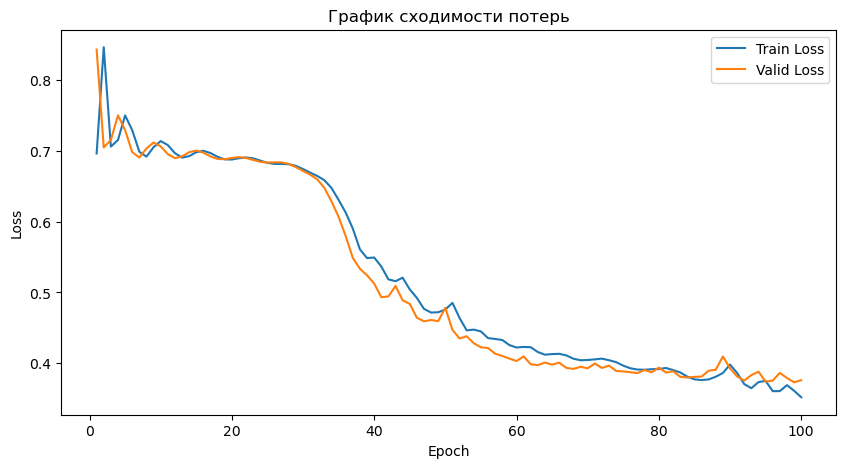

1. Сгенерированное имя: tliiud ozbdw
2. Сгенерированное имя: jqkpifklpsjl
3. Сгенерированное имя: kcsitnfdhjbt
4. Сгенерированное имя: mgepsiop pej
5. Сгенерированное имя: ddkejkwjpwc 
6. Сгенерированное имя:  hbalp<SOS>cmisj
7. Сгенерированное имя: kswlmoqqnrrz
8. Сгенерированное имя: scknrjx fdmc
9. Сгенерированное имя: kqsggwglskjr
10. Сгенерированное имя: qi<SOS>mr xqooww
AUC ROC: 0.9025


In [18]:
# RNN Model

rnn_gender = Model(vocab_size, embed_size, hidden_size, type='RNN', gender_output=True).to(device)
optimizer = optim.Adam(rnn_gender.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

train_losses, valid_losses, epochs_train = train_model(
    rnn_gender,
    train_loader,
    valid_loader,
    optimizer,
    criterion,
    patience=10,
    gender_mode=True
)

evaluation_model(rnn_gender, epochs_train, train_losses, valid_losses)

Epoch 1/100 finished. Train Loss: 0.6941, Valid Loss: 0.7486
Epoch 2/100 finished. Train Loss: 0.7511, Valid Loss: 0.6818
Epoch 3/100 finished. Train Loss: 0.6822, Valid Loss: 0.7135
Epoch 4/100 finished. Train Loss: 0.7131, Valid Loss: 0.7118
Epoch 5/100 finished. Train Loss: 0.7114, Valid Loss: 0.6831
Epoch 6/100 finished. Train Loss: 0.6831, Valid Loss: 0.6687
Epoch 7/100 finished. Train Loss: 0.6696, Valid Loss: 0.6732
Epoch 8/100 finished. Train Loss: 0.6751, Valid Loss: 0.6743
Epoch 9/100 finished. Train Loss: 0.6767, Valid Loss: 0.6615
Epoch 10/100 finished. Train Loss: 0.6639, Valid Loss: 0.6436
Epoch 11/100 finished. Train Loss: 0.6457, Valid Loss: 0.6321
Epoch 12/100 finished. Train Loss: 0.6339, Valid Loss: 0.6282
Epoch 13/100 finished. Train Loss: 0.6302, Valid Loss: 0.6214
Epoch 14/100 finished. Train Loss: 0.6242, Valid Loss: 0.6044
Epoch 15/100 finished. Train Loss: 0.6081, Valid Loss: 0.5824
Epoch 16/100 finished. Train Loss: 0.5871, Valid Loss: 0.5659
Epoch 17/100 fini

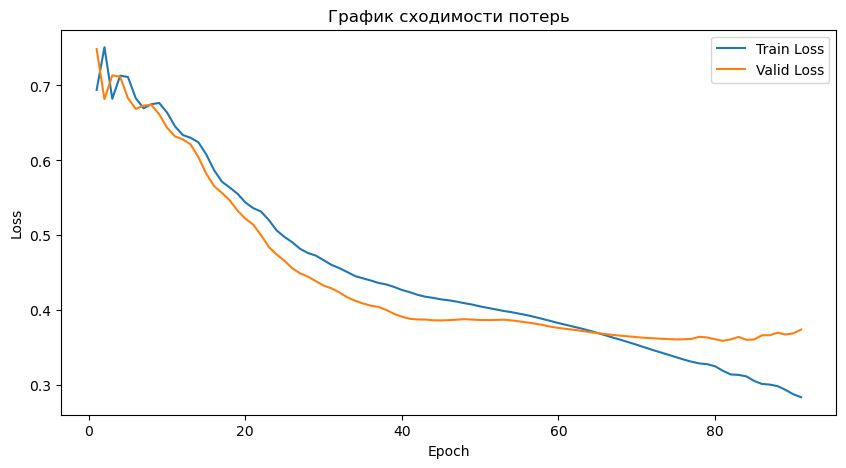

1. Сгенерированное имя: xaebfzglf<SOS>o
2. Сгенерированное имя: zhf
3. Сгенерированное имя: zlasagmoxjfy
4. Сгенерированное имя: 
5. Сгенерированное имя: f tqhqhckhsc
6. Сгенерированное имя: kkptljsmpe
7. Сгенерированное имя: eobjne qin f
8. Сгенерированное имя: llizztyodup<SOS>
9. Сгенерированное имя: mxwo<SOS>zfsaisy
10. Сгенерированное имя: txasaujc<SOS>amb
AUC ROC: 0.9160


In [19]:
# GRU Model

gru_gender = Model(vocab_size, embed_size, hidden_size, type='GRU', gender_output=True).to(device)
optimizer = optim.Adam(gru_gender.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

train_losses, valid_losses, epochs_train = train_model(
    gru_gender,
    train_loader,
    valid_loader,
    optimizer,
    criterion,
    patience=10,
    gender_mode=True
)

evaluation_model(gru_gender, epochs_train, train_losses, valid_losses)

Epoch 1/100 finished. Train Loss: 0.6921, Valid Loss: 0.6950
Epoch 2/100 finished. Train Loss: 0.6946, Valid Loss: 0.6876
Epoch 3/100 finished. Train Loss: 0.6880, Valid Loss: 0.6875
Epoch 4/100 finished. Train Loss: 0.6881, Valid Loss: 0.6787
Epoch 5/100 finished. Train Loss: 0.6789, Valid Loss: 0.6745
Epoch 6/100 finished. Train Loss: 0.6744, Valid Loss: 0.6684
Epoch 7/100 finished. Train Loss: 0.6683, Valid Loss: 0.6519
Epoch 8/100 finished. Train Loss: 0.6520, Valid Loss: 0.6319
Epoch 9/100 finished. Train Loss: 0.6324, Valid Loss: 0.6060
Epoch 10/100 finished. Train Loss: 0.6069, Valid Loss: 0.5729
Epoch 11/100 finished. Train Loss: 0.5758, Valid Loss: 0.5517
Epoch 12/100 finished. Train Loss: 0.5593, Valid Loss: 0.5397
Epoch 13/100 finished. Train Loss: 0.5462, Valid Loss: 0.5394
Epoch 14/100 finished. Train Loss: 0.5496, Valid Loss: 0.5310
Epoch 15/100 finished. Train Loss: 0.5494, Valid Loss: 0.5134
Epoch 16/100 finished. Train Loss: 0.5332, Valid Loss: 0.5007
Epoch 17/100 fini

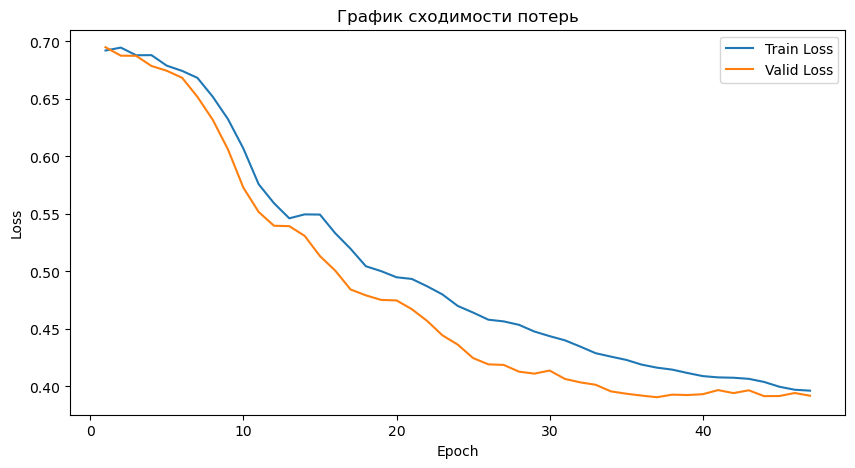

1. Сгенерированное имя: s dzn e<SOS>mudz
2. Сгенерированное имя: qzeitbookoun
3. Сгенерированное имя: s
4. Сгенерированное имя: ubwgfssfgqbk
5. Сгенерированное имя: kel utyz nch
6. Сгенерированное имя: ygvevmankzso
7. Сгенерированное имя: pnvrcxbdkul 
8. Сгенерированное имя: twcdkymrpt e
9. Сгенерированное имя: 
10. Сгенерированное имя: cmitwwggrgwy
AUC ROC: 0.8949


In [20]:
# LSTM Model

lstm_gender = Model(vocab_size, embed_size, hidden_size, type='LSTM', gender_output=True).to(device)
optimizer = optim.Adam(lstm_gender.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

train_losses, valid_losses, epochs_train = train_model(
    lstm_gender,
    train_loader,
    valid_loader,
    optimizer,
    criterion,
    patience=10,
    gender_mode=True
)

evaluation_model(lstm_gender, epochs_train, train_losses, valid_losses)

### 9. Исчезающий градиент

In [43]:
mean_lengths = round(train['Name'].apply(len).mean())

# Чтобы градиенты по позициям были сопоставимы между именами
train['Count'] = train['Name'].apply(len)
valid['Count'] = valid['Name'].apply(len)
train_fixed = train[train['Count'] == mean_lengths].reset_index(drop=True)
valid_fixed = valid[valid['Count'] == mean_lengths].reset_index(drop=True)

train_tensor_fixed = torch.tensor(
    list(train_fixed['Encoded'].values),
    dtype=torch.long
)

train_genders_fixed = torch.tensor(
    train_fixed['Gender'].values,
    dtype=torch.float
)

valid_tensor_fixed = torch.tensor(
    list(valid_fixed['Encoded'].values),
    dtype=torch.long
)

valid_genders_fixed = torch.tensor(
    valid_fixed['Gender'].values,
    dtype=torch.float
)

train_dataset_fixed = TensorDataset(train_tensor_fixed, train_genders_fixed)

train_loader_fixed = DataLoader(
    train_dataset_fixed,
    batch_size=1,  # важно для шага c
    shuffle=False
)


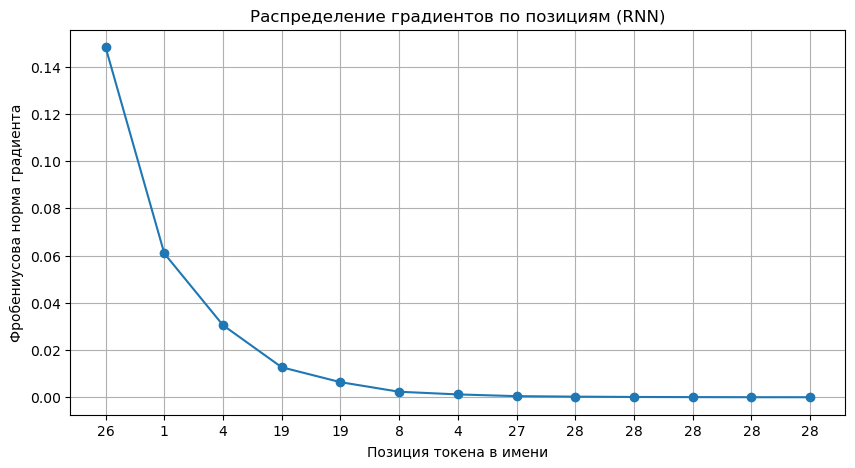

Градиенты по позициям (Фробениус): tensor([1.4819e-01, 6.0895e-02, 3.0495e-02, 1.2694e-02, 6.3877e-03, 2.3275e-03,
        1.1986e-03, 4.6367e-04, 2.5292e-04, 1.1912e-04, 5.9396e-05, 2.1597e-05,
        1.1198e-05])


In [100]:
# Функция для регистрации hook и сбора градиентов
def collect_gradients_for_name(model, x_batch, gender_label, logits_tokens=False):
    gradients_storage = []

    def embedding_backward_hook(module, grad_input, grad_output):
        # grad_output[0]: [batch_size, seq_len, embedding_size]
        gradients_storage.append(grad_output[0].detach().cpu())

    # Регистрируем hook
    hook_handle = model.embedding.register_full_backward_hook(embedding_backward_hook)

    criterion = torch.nn.CrossEntropyLoss() if logits_tokens else torch.nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    model.train()
    x_batch = x_batch.to(next(model.parameters()).device)
    gender_label = gender_label.to(next(model.parameters()).device)


    if logits_tokens:
        # Задача предсказания следующего токена
        logits_seq, _, _, _ = model(x_batch)          # [batch, seq_len, vocab_size]
        y_next = x_batch[:, 1:]                       # [batch, seq_len-1]
        logits_seq = logits_seq[:, :-1, :]            # [batch, seq_len-1, vocab_size]

        logits_seq = logits_seq.reshape(-1, logits_seq.shape[-1])
        y_next = y_next.reshape(-1)

        optimizer.zero_grad()
        loss = criterion(logits_seq, y_next)
        loss.backward()
        optimizer.step()

    else:
        # Классификация пола
        optimizer.zero_grad()
        _, _, logits_gender, _ = model(x_batch)
        logits_gender = logits_gender.view(-1)
        gender_label = gender_label.view(-1)
        loss = criterion(logits_gender, gender_label)
        loss.backward()
        optimizer.step()

    hook_handle.remove()
    return gradients_storage


# Функция для вычисления норм градиентов
def compute_gradient_norms(gradients_storage):
    # grad_tensor: [seq_len, n_tokens, embedding_size]
    grad_tensor = torch.stack(gradients_storage, dim=0).squeeze(1)  # убираем batch_size=1
    # Норма по embedding_size => скаляр на каждую позицию токена
    grad_norms = grad_tensor.norm(dim=-1)  # [seq_len, n_tokens]
    # Фробениусова норма по позиции (для batch_size=1 это просто норма по embedding)
    fro_norms = grad_tensor.view(len(gradients_storage), -1).norm(dim=1)  # [seq_len]
    return grad_tensor, grad_norms, fro_norms


# Функция для построения графика
def plot_gradient_norms(fro_norms, tokens_in_name, model_type='RNN'):
    plt.figure(figsize=(10, 5))
    plt.plot(fro_norms, marker='o')
    plt.xticks(range(len(tokens_in_name)), tokens_in_name)
    plt.xlabel("Позиция токена в имени")
    plt.ylabel("Фробениусова норма градиента")
    plt.title(f"Распределение градиентов по позициям ({model_type})")
    plt.grid(True)
    plt.show()


batch_size = 1
x_batch = train_tensor_fixed[0].unsqueeze(0)  # [1, seq_len]
gender_label = train_genders_fixed[0].unsqueeze(0)  # [1]

rnn_model = Model(vocab_size, embed_size, hidden_size, type='RNN', gender_output=True).to(device)

gradients_storage = collect_gradients_for_name(rnn_model, x_batch, gender_label)
grad_tensor, grad_norms, fro_norms = compute_gradient_norms(gradients_storage)

tokens_in_name = x_batch.squeeze(0).tolist()
plot_gradient_norms(fro_norms, tokens_in_name, model_type='RNN')

print("Градиенты по позициям (Фробениус):", fro_norms)

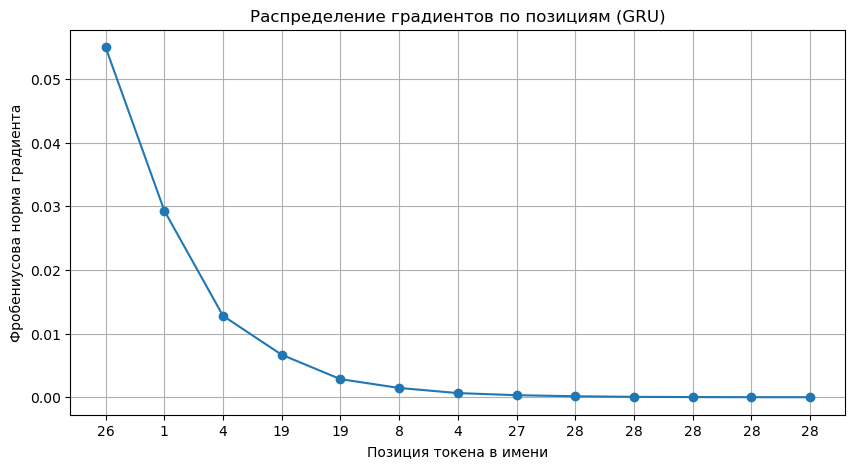

Градиенты по позициям (Фробениус): tensor([5.4978e-02, 2.9319e-02, 1.2791e-02, 6.6730e-03, 2.8457e-03, 1.4599e-03,
        6.5357e-04, 3.2279e-04, 1.5482e-04, 6.3688e-05, 2.9062e-05, 1.1447e-05,
        5.2131e-06])


In [97]:
gru_model = Model(vocab_size, embed_size, hidden_size, type='GRU', gender_output=True).to(device)

gradients_storage = collect_gradients_for_name(rnn_model, x_batch, gender_label)
grad_tensor, grad_norms, fro_norms = compute_gradient_norms(gradients_storage)

tokens_in_name = x_batch.squeeze(0).tolist()
plot_gradient_norms(fro_norms, tokens_in_name, model_type='GRU')

print("Градиенты по позициям (Фробениус):", fro_norms)

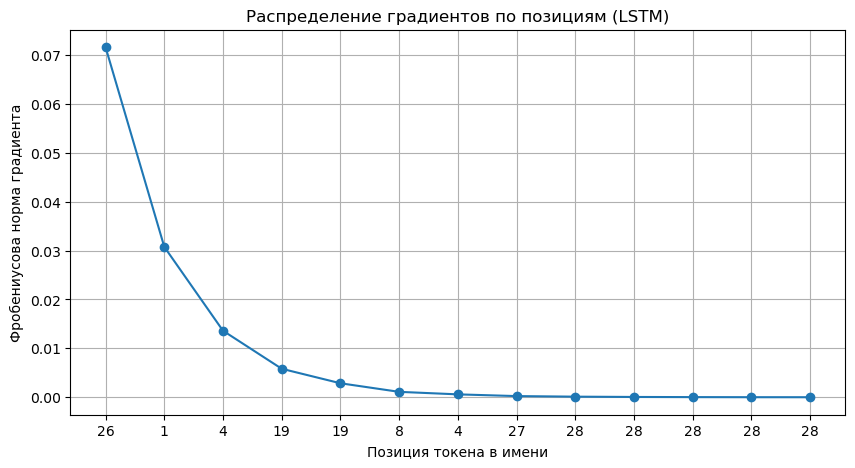

Градиенты по позициям (Фробениус): tensor([7.1601e-02, 3.0759e-02, 1.3604e-02, 5.8255e-03, 2.8607e-03, 1.1051e-03,
        5.9058e-04, 2.3780e-04, 1.1893e-04, 5.9235e-05, 2.8480e-05, 1.0033e-05,
        5.5821e-06])


In [101]:
lstm_model = Model(vocab_size, embed_size, hidden_size, type='LSTM', gender_output=True).to(device)

gradients_storage = collect_gradients_for_name(rnn_model, x_batch, gender_label)
grad_tensor, grad_norms, fro_norms = compute_gradient_norms(gradients_storage)

tokens_in_name = x_batch.squeeze(0).tolist()
plot_gradient_norms(fro_norms, tokens_in_name, model_type='LSTM')

print("Градиенты по позициям (Фробениус):", fro_norms)

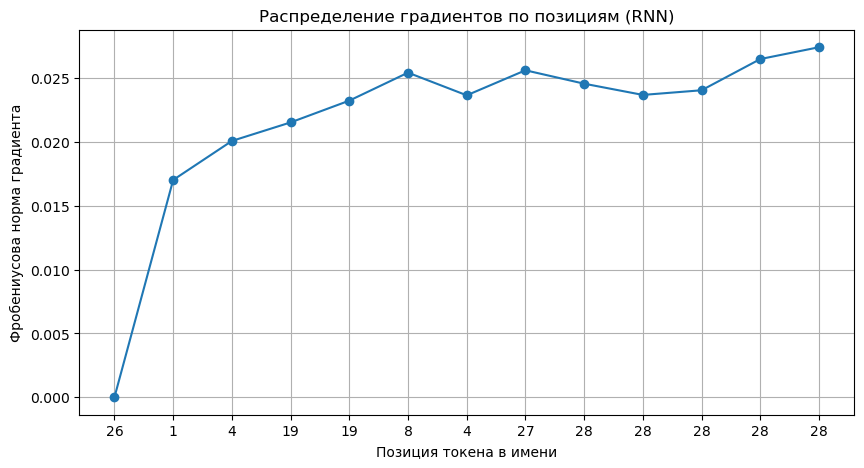

Градиенты по позициям (Фробениус): tensor([0.0000, 0.0170, 0.0201, 0.0215, 0.0232, 0.0254, 0.0236, 0.0256, 0.0246,
        0.0237, 0.0240, 0.0265, 0.0274])


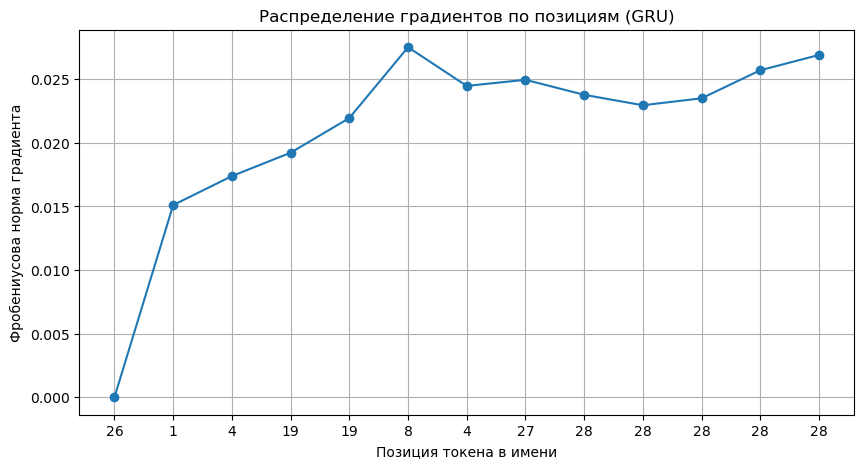

Градиенты по позициям (Фробениус): tensor([0.0000, 0.0151, 0.0174, 0.0192, 0.0219, 0.0275, 0.0245, 0.0250, 0.0238,
        0.0230, 0.0235, 0.0257, 0.0269])


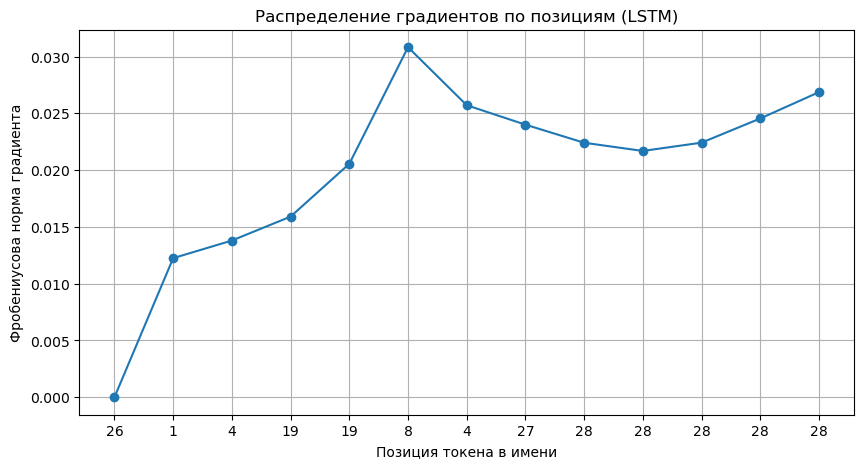

Градиенты по позициям (Фробениус): tensor([0.0000, 0.0122, 0.0138, 0.0159, 0.0206, 0.0308, 0.0257, 0.0240, 0.0224,
        0.0217, 0.0224, 0.0246, 0.0269])


In [103]:
def grad_tokens(model, model_type):
    gradients_storage = collect_gradients_for_name(rnn_model, x_batch, gender_label, logits_tokens=True)
    grad_tensor, grad_norms, fro_norms = compute_gradient_norms(gradients_storage)
    
    tokens_in_name = x_batch.squeeze(0).tolist()
    plot_gradient_norms(fro_norms, tokens_in_name, model_type=model_type)
    
    print("Градиенты по позициям (Фробениус):", fro_norms)

grad_tokens(rnn_model, model_type='RNN')
grad_tokens(gru_model, model_type='GRU')
grad_tokens(lstm_model, model_type='LSTM')

### 10. Многозадачное обучение

Epoch 1/100 | Gender: Train 0.6941, Valid 0.6933 | Letter: Train 3.3019, Valid 3.1179
Epoch 2/100 | Gender: Train 0.6935, Valid 0.6927 | Letter: Train 3.1123, Valid 2.9369
Epoch 3/100 | Gender: Train 0.6929, Valid 0.6922 | Letter: Train 2.9266, Valid 2.7580
Epoch 4/100 | Gender: Train 0.6924, Valid 0.6919 | Letter: Train 2.7431, Valid 2.5844
Epoch 5/100 | Gender: Train 0.6920, Valid 0.6917 | Letter: Train 2.5653, Valid 2.4241
Epoch 6/100 | Gender: Train 0.6918, Valid 0.6915 | Letter: Train 2.4015, Valid 2.2854
Epoch 7/100 | Gender: Train 0.6917, Valid 0.6915 | Letter: Train 2.2601, Valid 2.1709
Epoch 8/100 | Gender: Train 0.6917, Valid 0.6914 | Letter: Train 2.1438, Valid 2.0774
Epoch 9/100 | Gender: Train 0.6916, Valid 0.6914 | Letter: Train 2.0492, Valid 1.9998
Epoch 10/100 | Gender: Train 0.6916, Valid 0.6913 | Letter: Train 1.9708, Valid 1.9352
Epoch 11/100 | Gender: Train 0.6916, Valid 0.6913 | Letter: Train 1.9052, Valid 1.8853
Epoch 12/100 | Gender: Train 0.6915, Valid 0.6911 | 

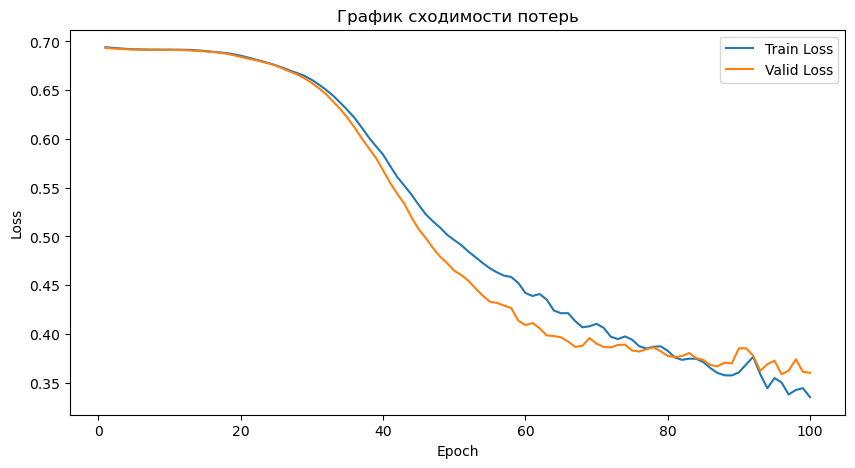

1. Сгенерированное имя: mardne
2. Сгенерированное имя: marie
3. Сгенерированное имя: nause
4. Сгенерированное имя: aristo
5. Сгенерированное имя: marina
6. Сгенерированное имя: kasttin
7. Сгенерированное имя: amarie
8. Сгенерированное имя: kere
9. Сгенерированное имя:             
10. Сгенерированное имя: derene
AUC ROC: 0.9108


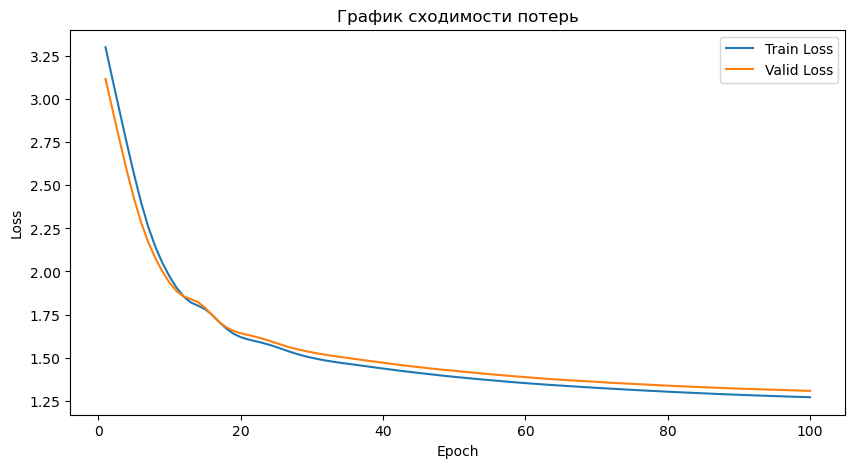

1. Сгенерированное имя: mariele
2. Сгенерированное имя: saran
3. Сгенерированное имя: andele
4. Сгенерированное имя: mardo
5. Сгенерированное имя: elie
6. Сгенерированное имя: marie
7. Сгенерированное имя: storie
8. Сгенерированное имя: elan
9. Сгенерированное имя: alena
10. Сгенерированное имя: devie
AUC ROC: 0.9108


In [174]:
def train_epoch_multitask(model, train_loader, optimizer, criterion_gender, criterion_letter):
    """
    Один проход по обучающему набору для многозадачного обучения:
    - gender_output (BCE)
    - letter prediction (CrossEntropy)
    """
    model.train()
    epoch_loss_gender = 0
    epoch_loss_letter = 0
    
    for x_batch, gender_labels in train_loader:
        x_batch = x_batch.to(device)
        gender_labels = gender_labels.to(device)

        optimizer.zero_grad()

        # Forward pass
        logits_letters, _, logits_gender, _ = model(x_batch)
        
        # Gender loss
        logits_gender = logits_gender.view(-1)
        gender_labels_flat = gender_labels.view(-1)
        loss_gender = criterion_gender(logits_gender, gender_labels_flat)
        
        # Letter prediction loss (next-char)
        targets_letters = x_batch[:, 1:]          # сдвиг на 1
        preds_letters = logits_letters[:, :-1, :] # убираем последний токен
        loss_letter = criterion_letter(preds_letters.reshape(-1, vocab_size),
                                       targets_letters.reshape(-1))
        
        # Совмещаем потери
        total_loss = loss_gender + loss_letter
        total_loss.backward()
        optimizer.step()

        epoch_loss_gender += loss_gender.item()
        epoch_loss_letter += loss_letter.item()
    
    return epoch_loss_gender / len(train_loader), epoch_loss_letter / len(train_loader)


def validate_epoch_multitask(model, valid_loader, criterion_gender, criterion_letter):
    model.eval()
    valid_loss_gender = 0
    valid_loss_letter = 0

    with torch.no_grad():
        for x_batch, gender_labels in valid_loader:
            x_batch = x_batch.to(device)
            gender_labels = gender_labels.to(device)

            logits_letters, _, logits_gender, _ = model(x_batch)

            # Gender
            logits_gender = logits_gender.view(-1)
            gender_labels_flat = gender_labels.view(-1)
            loss_gender = criterion_gender(logits_gender, gender_labels_flat)

            # Letters
            targets_letters = x_batch[:, 1:]
            preds_letters = logits_letters[:, :-1, :]
            loss_letter = criterion_letter(preds_letters.reshape(-1, vocab_size),
                                           targets_letters.reshape(-1))

            valid_loss_gender += loss_gender.item()
            valid_loss_letter += loss_letter.item()

    return valid_loss_gender / len(valid_loader), valid_loss_letter / len(valid_loader)


def train_model_multitask(model, train_loader, valid_loader, optimizer,
                          epochs=100, patience=5):
    
    criterion_gender = nn.BCEWithLogitsLoss()
    criterion_letter = nn.CrossEntropyLoss()

    best_gender = float('inf')
    best_letter = float('inf')
    counter_gender = 0
    counter_letter = 0

    train_losses_gender, valid_losses_gender = [], []
    train_losses_letter, valid_losses_letter = [], []
    
    for epoch in range(epochs):
        tr_loss_gender, tr_loss_letter = train_epoch_multitask(
            model, train_loader, optimizer, criterion_gender, criterion_letter)
        val_loss_gender, val_loss_letter = validate_epoch_multitask(
            model, valid_loader, criterion_gender, criterion_letter)
        
        train_losses_gender.append(tr_loss_gender)
        valid_losses_gender.append(val_loss_gender)
        train_losses_letter.append(tr_loss_letter)
        valid_losses_letter.append(val_loss_letter)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Gender: Train {tr_loss_gender:.4f}, Valid {val_loss_gender:.4f} | "
              f"Letter: Train {tr_loss_letter:.4f}, Valid {val_loss_letter:.4f}")

        # Early stopping
        if val_loss_gender < best_gender:
            best_gender = val_loss_gender
            counter_gender = 0
        else:
            counter_gender += 1

        if val_loss_letter < best_letter:
            best_letter = val_loss_letter
            counter_letter = 0
        else:
            counter_letter += 1

        if counter_gender >= patience or counter_letter >= patience:
            print("Early stopping triggered!")
            break

    return train_losses_gender, valid_losses_gender, train_losses_letter, valid_losses_letter, epoch + 1


lstm = Model(vocab_size, embed_size, hidden_size, type='LSTM', gender_output=True).to(device)
optimizer = optim.Adam(lstm.parameters(), lr=1e-3)

train_losses_gender, valid_losses_gender, train_losses_letter, valid_losses_letter, epochs_train = train_model_multitask(
    lstm,
    train_loader,
    valid_loader,
    optimizer,
    epochs=100,
    patience=10
)

# Оценка
evaluation_model(lstm, epochs_train, train_losses_gender, valid_losses_gender)
evaluation_model(lstm, epochs_train, train_losses_letter, valid_losses_letter)


### 11. Визуализация эмбеддингов

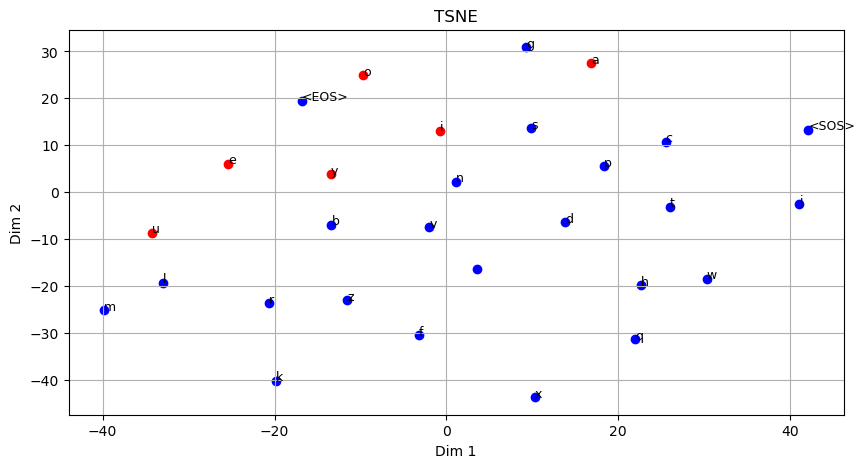

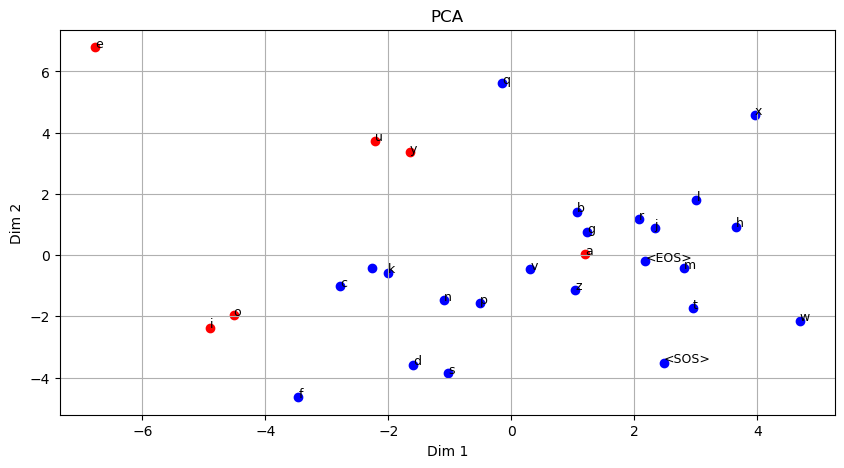

In [176]:
# 1. Получаем веса embedding слоя
embeddings = lstm.embedding.weight.detach().cpu().numpy()  # [n_tokens, embed_size]

# 2. Сжимаем до 2D с помощью TSNE
tsne = TSNE(n_components=2, random_state=42, perplexity=10)
embeddings_tsne = tsne.fit_transform(embeddings)

# 3. Сжимаем до 2D с помощью PCA
pca = PCA(n_components=2)
embeddings_pca = pca.fit_transform(embeddings)

# 4. Разделяем токены на гласные и согласные
vowels = set('aeiouy')  # пример для латиницы
is_vowel = [c in vowels for c in all_chars]

# 5. Функция для построения scatter plot
def plot_embeddings(embeddings_2d, title="Embeddings 2D"):
    plt.figure(figsize=(10, 5))
    for i, (x, y) in enumerate(embeddings_2d):
        color = 'red' if is_vowel[i] else 'blue'
        plt.scatter(x, y, color=color)
        plt.text(x, y, all_chars[i], fontsize=9)
    plt.title(title)
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.grid(True)
    plt.show()

# 6. Визуализируем
plot_embeddings(embeddings_tsne, title="TSNE")
plot_embeddings(embeddings_pca, title="PCA")

### 12. Сохранение модели

In [178]:
# Сохраняем модель
model_file = "data/multitask_model.pkl"

# Сохраняем словарь модели и optimizer
with open(model_file, "wb") as f:
    pickle.dump({
        'model_state_dict': lstm.state_dict(),
        'vocab_size': vocab_size,
        'embed_size': embed_size,
        'hidden_size': hidden_size,
        'model_type': 'LSTM'
    }, f)

In [181]:
# Загружаем модель
with open("data/multitask_model.pkl", "rb") as f:
    checkpoint = pickle.load(f)

loaded_model = Model(
    vocab_size=checkpoint['vocab_size'],
    embed_size=checkpoint['embed_size'],
    hidden_size=checkpoint['hidden_size'],
    type=checkpoint['model_type'],
    gender_output=True
).to(device)

loaded_model.load_state_dict(checkpoint['model_state_dict'])
loaded_model.eval()

Model(
  (embedding): Embedding(29, 128)
  (W_xi): Linear(in_features=128, out_features=256, bias=True)
  (W_hi): Linear(in_features=256, out_features=256, bias=True)
  (W_xf): Linear(in_features=128, out_features=256, bias=True)
  (W_hf): Linear(in_features=256, out_features=256, bias=True)
  (W_xo): Linear(in_features=128, out_features=256, bias=True)
  (W_ho): Linear(in_features=256, out_features=256, bias=True)
  (W_xc): Linear(in_features=128, out_features=256, bias=True)
  (W_hc): Linear(in_features=256, out_features=256, bias=True)
  (fc_token): Linear(in_features=256, out_features=29, bias=True)
  (fc_gender): Linear(in_features=256, out_features=1, bias=True)
)

In [184]:
test_sequences = torch.tensor(list(test['Encoded'].values), dtype=torch.long)  # [num_samples, seq_len] # Последовательности токенов для теста
test_genders = torch.tensor(test['Gender'].values, dtype=torch.float)  # [num_samples] Метки пола

test_dataset = TensorDataset(test_sequences, test_genders)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

preds = []
test_genders_list = []

with torch.no_grad():
    for x_batch, gender_labels in test_loader:
        x_batch = x_batch.to(device)
        gender_labels = gender_labels.to(device)

        _, _, logits_gender, _ = loaded_model(x_batch)
        probs = torch.sigmoid(logits_gender).cpu().numpy()  # вероятность пола
        preds.extend(probs.flatten())
        test_genders_list.extend(gender_labels.cpu().numpy().flatten())

# Сохраняем предсказания
df_preds = pd.DataFrame({
    "predicted_gender": preds
})

df_preds.to_csv("data/test_predictions.csv", index=False)

# ROC AUC
roc_auc = roc_auc_score(test_genders_list, preds)
print(f"ROC AUC: {roc_auc:.4f}")

ROC AUC: 0.9080
